# Spatial Analysis
### Imports and constants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio
from datetime import datetime, timedelta
import geopandas as gpd
from shapely.geometry import Point
from esda.moran import Moran_Local
from libpysal.weights import Queen
from pyproj import Transformer
import esda
import libpysal

NIBRS_CATEGORIES = {
    'ASSAULT': ['13A', '13B', '13C'],
    'THEFT': ['23A', '23B', '23C', '23D', '23E', '23F', '23G', '23H'],
    'SEX CRIMES': ['36A', '36B', '11A', '11B', '11C', '11D'],
    'HOMICIDE': ['09A', '09B', '09C'],
    'GROUP B': ['90A', '90F','90B','90C','90D','90E','90H','90H','90I','90J','90Z'],
    'FRAUD': ['26A', '26B', '26C', '26D', '26E'],
    'DRUG OFFENSES': ['35A', '35B'],
    'BURGLARY': ['220']
}

# Function to map NIBRS code to category
def map_to_category(nibrs_code):
    """
    Map NIBRS code to simplified crime types.
    """
    # Convert to string and strip whitespace for consistent comparison
    nibrs_code = str(nibrs_code).strip()

    if nibrs_code in NIBRS_CATEGORIES['ASSAULT'] or nibrs_code in NIBRS_CATEGORIES['HOMICIDE']:
        return "VIOLENT CRIME"
    elif nibrs_code in NIBRS_CATEGORIES['SEX CRIMES']:
        return "SEX CRIMES"
    elif nibrs_code in NIBRS_CATEGORIES['THEFT']:
        return "THEFT"
    else:
        return 'OTHER'

## Pre-processing

In [2]:
df = pd.read_csv('../data/cleaned_2021-jan2025.csv')
city_bounds = gpd.read_file('../data/city_bounds/stl_boundary.shp')
neighborhood_bounds = gpd.read_file('../data/neighborhoods/Neighborhoods.shp')
neighborhood_pop = pd.read_csv('../data/neighborhoods/neighborhood_populations.csv')

# Identify rows with any missing spatial or time data
missing_data_mask = (
    df['Latitude'].isna() |
    df['Longitude'].isna()
)

# Count missing values before dropping
print(f"Rows with missing latitude: {df['Latitude'].isna().sum()}")
print(f"Rows with missing longitude: {df['Longitude'].isna().sum()}")
print(f"Total rows to be removed due to missing essential data: {missing_data_mask.sum()}")

# drop
df = df[~missing_data_mask]

# add crime category to df
df['crime_category'] = df['NIBRS'].apply(map_to_category)

# Convert date column to datetime format
df['IncidentDate'] = pd.to_datetime(df['IncidentDate'], format="mixed", dayfirst=False)

# remove any datapoints that fall outside the city limits
points = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))
points.set_crs(epsg=4326, inplace=True)

if city_bounds.crs != points.crs:
    points = points.to_crs(city_bounds.crs)

within_points = gpd.sjoin(points, city_bounds, how='inner', predicate = 'within')
columns_to_drop = ['index_right'] + list(city_bounds.columns)
within_points = within_points.drop(columns=columns_to_drop)
df = within_points

C:\Users\jz043x\AppData\Local\Temp\ipykernel_23100\704294576.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/cleaned_2021-jan2025.csv')


Rows with missing latitude: 2665
Rows with missing longitude: 2665
Total rows to be removed due to missing essential data: 2665


Total Points outside city limits: 2180


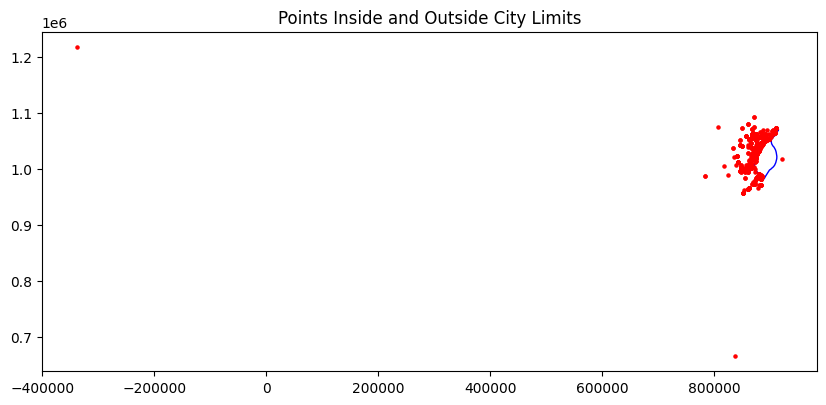

In [3]:
# PLOT outside points to confirm
outside_points = points[~points.index.isin(within_points.index)]

print(f"Total Points outside city limits: {len(outside_points)}")

fig, ax = plt.subplots(figsize=(10, 10))
city_bounds.plot(ax=ax, edgecolor='blue', facecolor='none')
outside_points[(outside_points['IncidentDate'] >= '2022-01-01') & (outside_points['IncidentDate'] < '2023-01-01')].plot(ax=ax, color='red', markersize=5, label='Points Outside City Limits')
plt.title('Points Inside and Outside City Limits')

# Show plot
plt.show()

## Analysis by Neighborhood

In [4]:
def create_chloropleth(dataframe, title, column, names=False):
    # Create the choropleth map
    fig, ax = plt.subplots(figsize=(12, 12))
    dataframe.plot(column=column, cmap="OrRd", linewidth=0.8, edgecolor="0.8", ax=ax, legend=True, legend_kwds={"label": "Crime Count", "orientation": "horizontal"})
    
    # Add neighborhood labels
    if names:
        for idx, row in dataframe.iterrows():
            centroid = row.geometry.centroid
            ax.text(centroid.x, centroid.y, row["NHD_NAME"], fontsize=8, ha="center", va="center")
        
    ax.set_title(title)
    ax.axis("off")
    
    plt.tight_layout()
    plt.show()


### We should count crimes using the neighborhood bounds because names used in the NIBRS data are inconsistent

In [5]:
# convert to gdf geometry points
points = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude), crs="EPSG:4326")

# Ensure both GeoDataFrames have the same CRS
if points.crs != neighborhood_bounds.crs:
    points = points.to_crs(neighborhood_bounds.crs)

# Perform spatial join to associate points with neighborhoods
joined = gpd.sjoin(points, neighborhood_bounds, how="left", predicate="within")

neighborhood_crimes = joined.groupby('NHD_NAME').agg(
    CrimeCount=('IncidentNum', 'count'),
    THEFT=('crime_category', lambda x: (x == 'THEFT').sum()),
    SEX_CRIMES=('crime_category', lambda x: (x == 'SEX CRIMES').sum()),
    OTHER_CRIMES=('crime_category', lambda x: (x == 'OTHER').sum()),
    GUN_CRIMES=('FirearmUsed', lambda x: (x == 'Yes').sum()),
    VIOLENT_CRIME=('crime_category', lambda x: (x == 'VIOLENT CRIME').sum())
).reset_index()

neighborhood_crimes = neighborhood_bounds.merge(neighborhood_crimes, left_on='NHD_NAME', right_on='NHD_NAME')

# merge with population
neighborhood_crimes = neighborhood_crimes.merge(neighborhood_pop, left_on="NHD_NAME", right_on="Neighborhood", how="left")


# neighborhood_crimes.head()

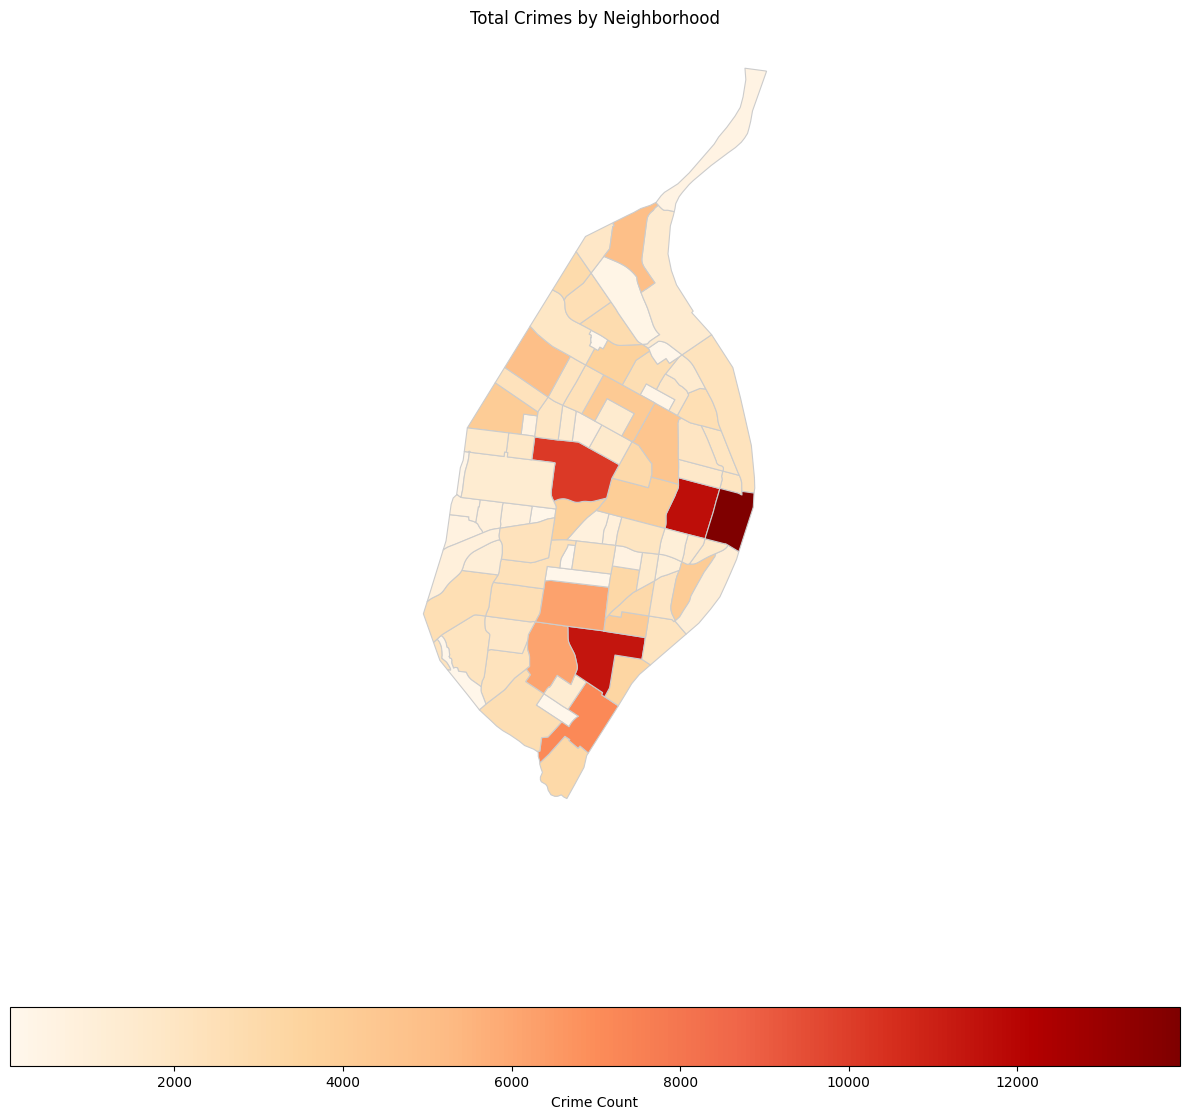

In [6]:
create_chloropleth(neighborhood_crimes, "Total Crimes by Neighborhood", "CrimeCount")

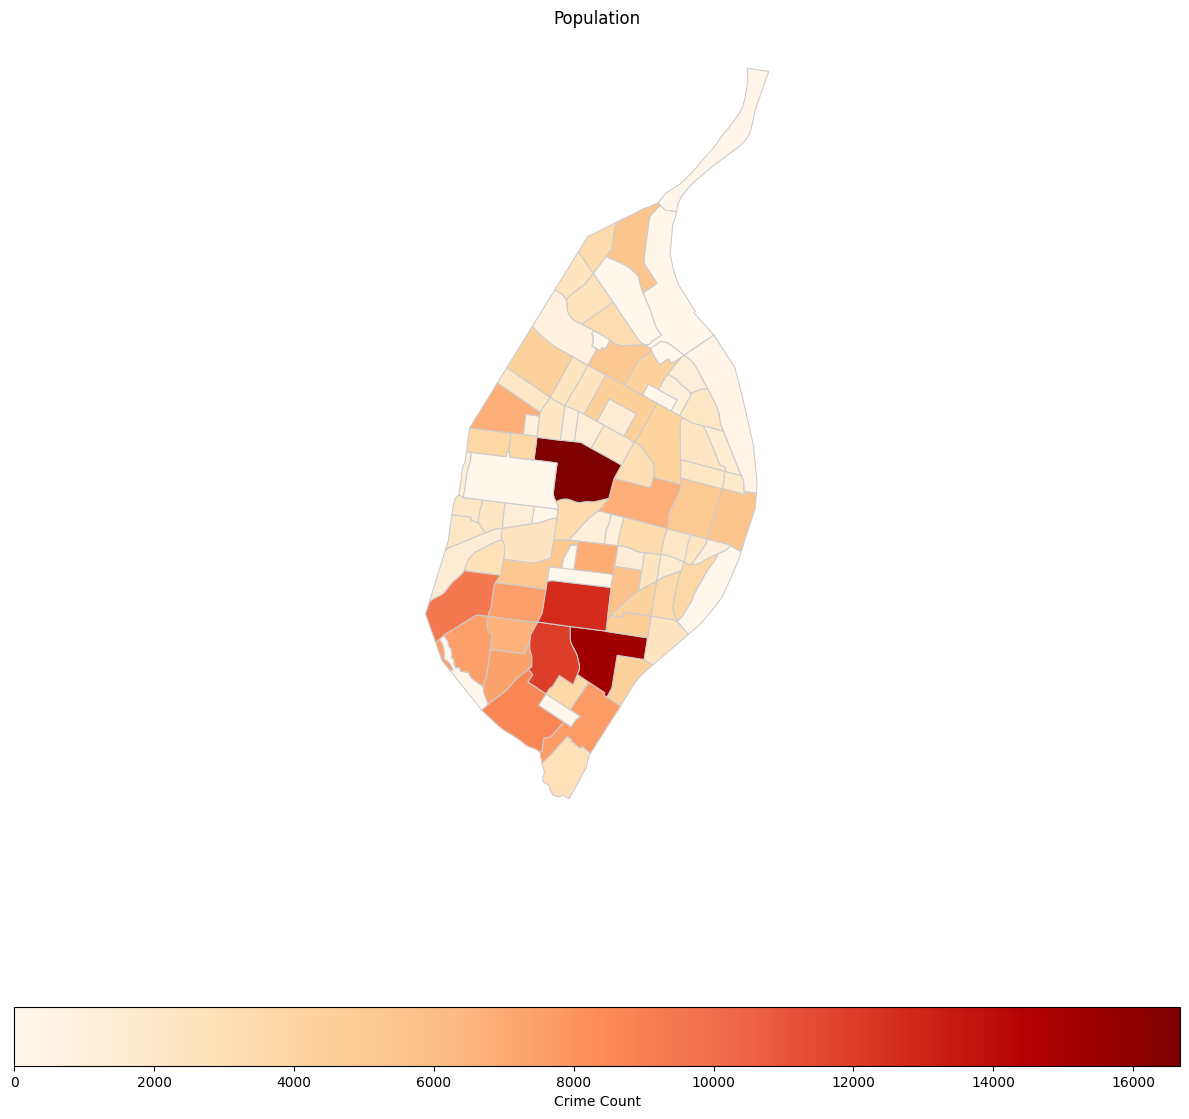

In [7]:
create_chloropleth(neighborhood_crimes, "Population", "Population")

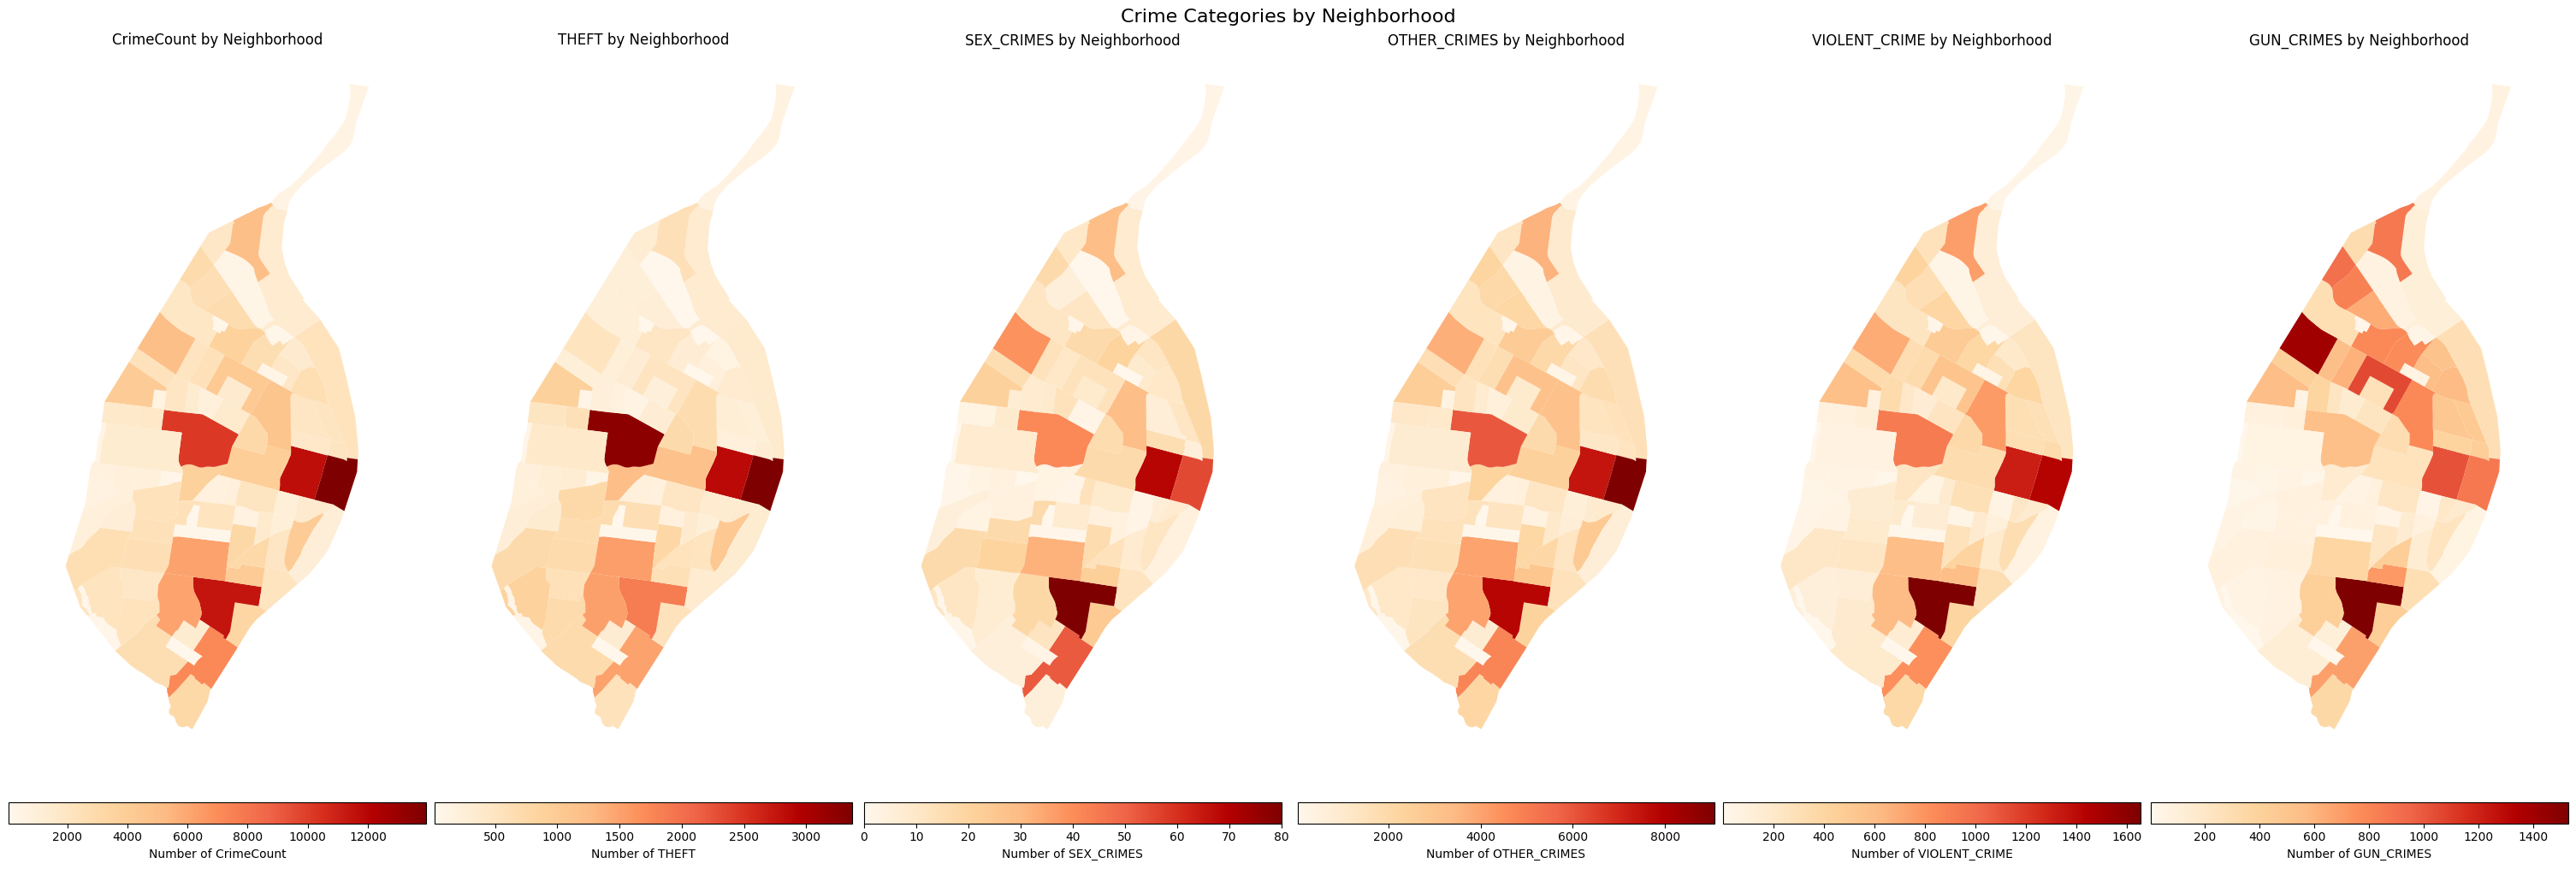

In [8]:
# List of crime categories to plot
crime_categories = ['CrimeCount', 'THEFT', 'SEX_CRIMES', 'OTHER_CRIMES', 'VIOLENT_CRIME', "GUN_CRIMES"]

# Number of crime categories
num_categories = len(crime_categories)

# Create subplots
fig, axs = plt.subplots(1, num_categories, figsize=(5 * num_categories, 10), constrained_layout=True)

# Plot each crime category as a choropleth map
for i, category in enumerate(crime_categories):
    neighborhood_crimes.plot(column=category, ax=axs[i], legend=True, cmap='OrRd', 
                   legend_kwds={'label': f"Number of {category}",
                                'orientation': "horizontal"})

    axs[i].set_title(f"{category} by Neighborhood")
    axs[i].axis('off')

# Set a main title for the whole figure
plt.suptitle('Crime Categories by Neighborhood', fontsize=16)

# Show plot
plt.show()

### Crime count adjusted for population

In [9]:
neighborhood_crimes["PopCrime"] = neighborhood_crimes["CrimeCount"]/neighborhood_crimes["Population"]

#stats for over 400 population
neighborhood_crimes["PopCrime"][neighborhood_crimes['Population'] > 400].describe()

count    74.000000
mean      0.801831
std       0.442483
min       0.255129
25%       0.502900
50%       0.718548
75%       0.995162
max       2.560088
Name: PopCrime, dtype: float64

In [10]:
# stats for under 400 and not infinity
neighborhood_crimes["PopCrime"][(neighborhood_crimes['Population'] < 400) & (~np.isinf(neighborhood_crimes['PopCrime']))].describe()

count     12.000000
mean      31.061029
std       60.553759
min        1.556886
25%        7.336709
50%       12.714286
75%       23.692500
max      221.000000
Name: PopCrime, dtype: float64

In [11]:
outlier_neighborhoods = neighborhood_crimes[(neighborhood_crimes['Population'] < 400)]
inlier_neighborhoods = neighborhood_crimes[(neighborhood_crimes['Population'] > 400)]

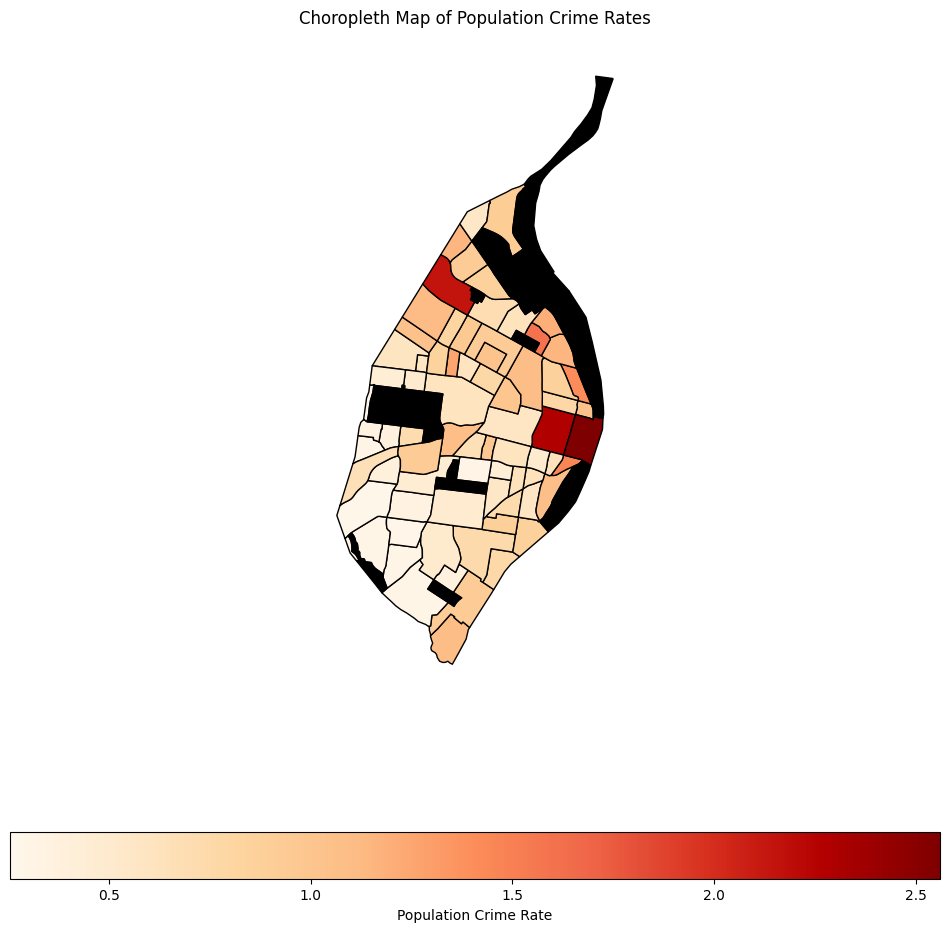

In [12]:
# Plotting the GeoDataFrame with the "PopCrime" column
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
inlier_neighborhoods.plot(column='PopCrime', ax=ax, legend=True,
         legend_kwds={'label': "Population Crime Rate",
                      'orientation': "horizontal"},
         cmap='OrRd',  
         edgecolor='black')

# Overlay the second GeoDataFrame with black fill color
outlier_neighborhoods.plot(ax=ax, color='black', edgecolor='black')

# Customize the plot with titles and labels
ax.set_title('Choropleth Map of Population Crime Rates')
ax.set_axis_off()  # Turn off the axis

# Show the plot
plt.show()

In [13]:
pop_crime_categories = ['THEFT', 'SEX_CRIMES', 'OTHER_CRIMES', 'VIOLENT_CRIME', "GUN_CRIMES"]
for category in pop_crime_categories:
    neighborhood_crimes['Pop'+category] = neighborhood_crimes[category]/neighborhood_crimes["Population"]

outlier_neighborhoods = neighborhood_crimes[(neighborhood_crimes['Population'] < 400)]
inlier_neighborhoods = neighborhood_crimes[(neighborhood_crimes['Population'] > 400)]

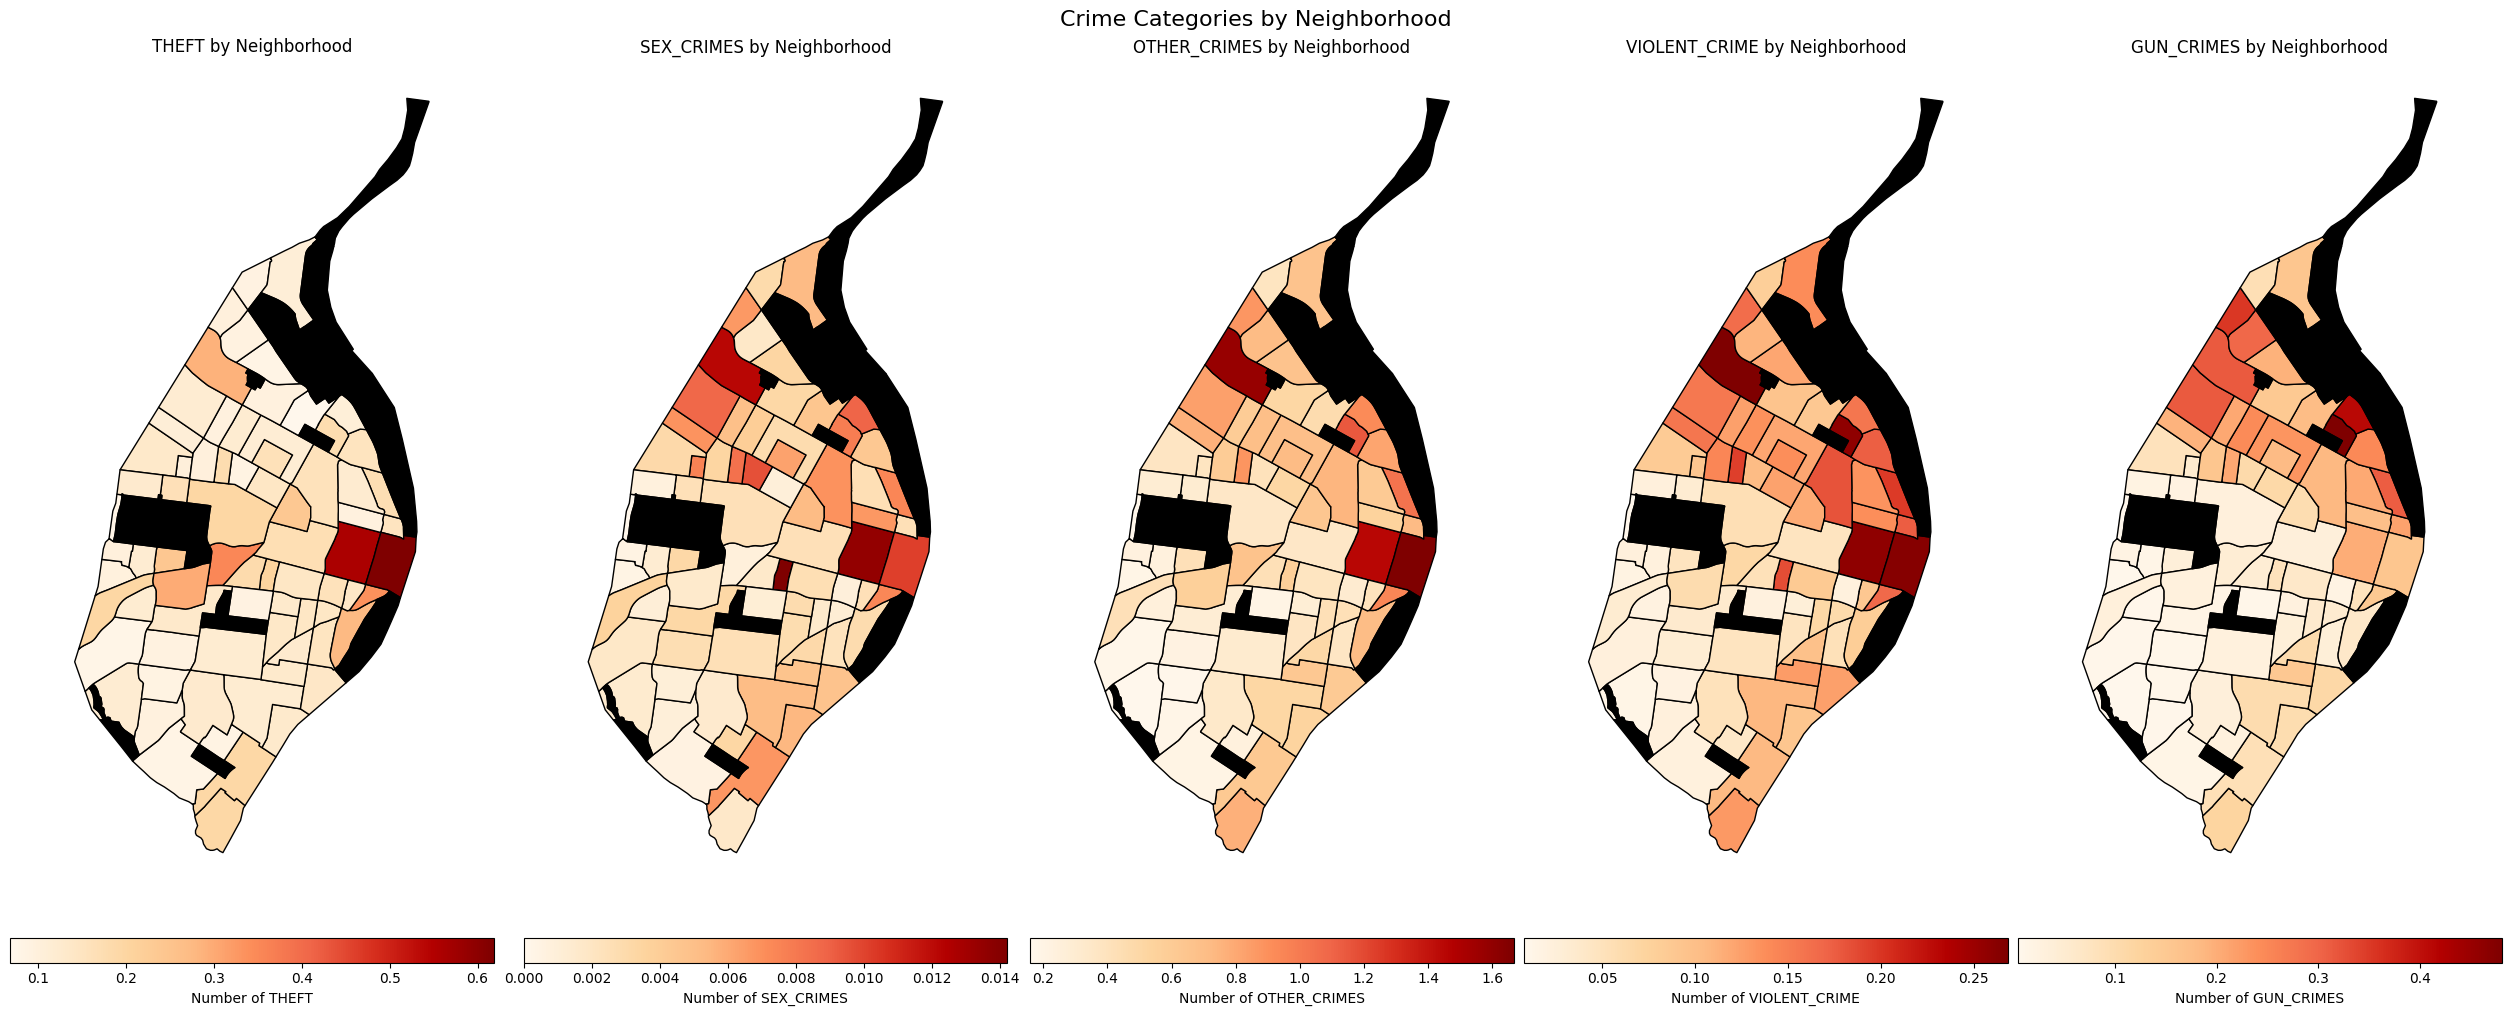

In [14]:
num_categories = len(pop_crime_categories)

# Create subplots
fig, axs = plt.subplots(1, num_categories, figsize=(5 * num_categories, 10), constrained_layout=True)


# Plot each crime category as a choropleth map
for i, category in enumerate(pop_crime_categories):
    inlier_neighborhoods.plot(column=('Pop' + category), ax=axs[i], legend=True,
                              legend_kwds={'label': f"Number of {category}",
                                           'orientation': "horizontal"},
                              cmap='OrRd', 
                              edgecolor='black')

    # Overlay the second GeoDataFrame with black fill color
    outlier_neighborhoods.plot(ax=axs[i], color='black', edgecolor='black')

    axs[i].set_title(f"{category} by Neighborhood")
    axs[i].axis('off')

# Set a main title for the whole figure
plt.suptitle('Crime Categories by Neighborhood', fontsize=16)

# Show plot
plt.show()

# Analysis by Lat/Long Bins

### Several papers have shown the effectiveness of a CNN-LSTM combination model, so we want to create an "image" where each pixel is a lat/long bucket and the value of the color is the amount of that crime that occurred in that location. Let's create the image.

In [15]:
# Define the grid size (e.g., 0.01 degrees for a medium-sized city)
lat_min, lat_max = df['Latitude'].min(), df['Latitude'].max()
lon_min, lon_max = df['Longitude'].min(), df['Longitude'].max()
lat_bins = np.arange(lat_min, lat_max, 0.001)
lon_bins = np.arange(lon_min, lon_max, 0.001)

# print(lat_min, lat_max, len(lat_bins))
# print(lon_min, lon_max, len(lon_bins))

heatmap, lat_edges, lon_edges = np.histogram2d(df['Latitude'], df['Longitude'], bins=[lat_bins, lon_bins])

In [16]:
def plot_heatmap(heatmap, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(heatmap, origin='lower', aspect='equal', cmap='hot', interpolation='nearest')
    plt.colorbar(label='Occurrences')
    plt.title(title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

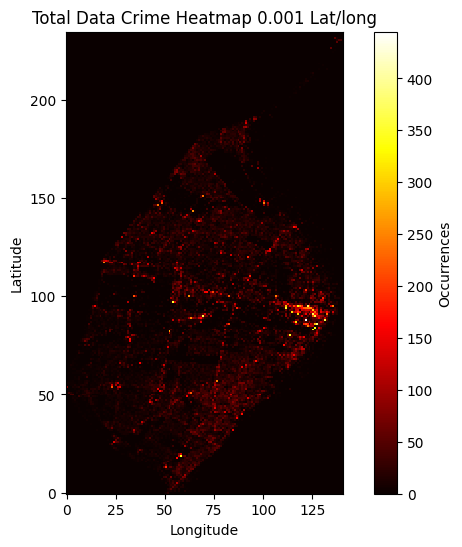

In [17]:
plot_heatmap(heatmap, "Total Data Crime Heatmap 0.001 Lat/long")

In [18]:
# Find the bin with the highest value
max_value_index = np.unravel_index(np.argmax(heatmap, axis=None), heatmap.shape)
max_lat_index, max_lon_index = max_value_index

# Determine the latitude and longitude range of the bin with the highest value
lat_range = (lat_edges[max_lat_index], lat_edges[max_lat_index + 1])
lon_range = (lon_edges[max_lon_index], lon_edges[max_lon_index + 1])

# Print the results
print(f'Bin with highest value: {heatmap[max_lat_index, max_lon_index]}')
print(f'Latitude range: {lat_range}')
print(f'Longitude range: {lon_range}')

Bin with highest value: 445.0
Latitude range: (38.6255699999998, 38.626569999999795)
Longitude range: (-90.19850399999942, -90.19750399999941)


In [19]:
points_within_bounds = df[
    (df['Latitude'] >= lat_range[0]) & (df['Latitude'] < lat_range[1]) &
    (df['Longitude'] >= lon_range[0]) & (df['Longitude'] < lon_range[1])
]

# Display the points within the bounds
# print(list(points_within_bounds['IncidentLocation'])[:400])
points_within_bounds.head(10)['IncidentLocation']

357     200 S TUCKER BLVD
537     200 S TUCKER BLVD
939     200 S TUCKER BLVD
940     200 S TUCKER BLVD
1064    200 S TUCKER BLVD
1450    200 S TUCKER BLVD
3365    200 S TUCKER BLVD
3639    200 S TUCKER BLVD
4216    200 S TUCKER BLVD
4287    200 S TUCKER BLVD
Name: IncidentLocation, dtype: object

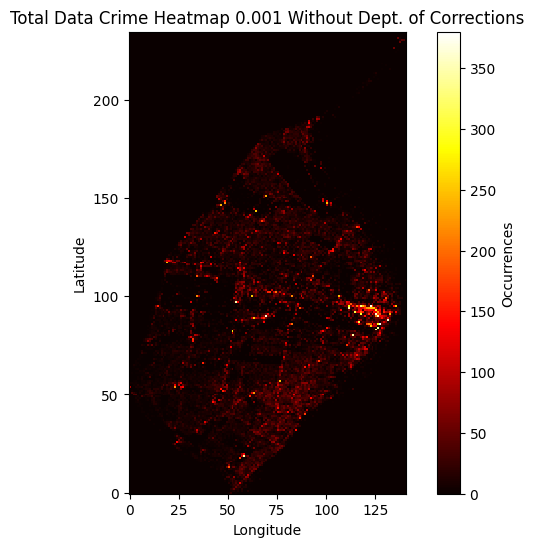

In [20]:
lat_bins = np.arange(lat_min, lat_max, 0.001)
lon_bins = np.arange(lon_min, lon_max, 0.001)

# print(lat_min, lat_max, len(lat_bins))
# print(lon_min, lon_max, len(lon_bins))

#filter out dept. of corrections points
df = df[df['IncidentLocation'] != '200 S TUCKER BLVD']

heatmap, lat_edges, lon_edges = np.histogram2d(df['Latitude'], df['Longitude'], bins=[lat_bins, lon_bins])
plot_heatmap(heatmap, "Total Data Crime Heatmap 0.001 Without Dept. of Corrections")

In [21]:
# Find the bin with the highest value
max_value_index = np.unravel_index(np.argmax(heatmap, axis=None), heatmap.shape)
max_lat_index, max_lon_index = max_value_index

# Determine the latitude and longitude range of the bin with the highest value
lat_range = (lat_edges[max_lat_index], lat_edges[max_lat_index + 1])
lon_range = (lon_edges[max_lon_index], lon_edges[max_lon_index + 1])

# Print the results
print(f'Bin with highest value: {heatmap[max_lat_index, max_lon_index]}')
print(f'Latitude range: {lat_range}')
print(f'Longitude range: {lon_range}')

points_within_bounds = df[
    (df['Latitude'] >= lat_range[0]) & (df['Latitude'] < lat_range[1]) &
    (df['Longitude'] >= lon_range[0]) & (df['Longitude'] < lon_range[1])
]

# Display the points within the bounds
# print(list(points_within_bounds['IncidentLocation'])[:400])
points_within_bounds.head(10)['IncidentLocation']

Bin with highest value: 380.0
Latitude range: (38.6235699999998, 38.6245699999998)
Longitude range: (-90.19250399999939, -90.19150399999938)


1095     651 CLARK AVE
2252     601 CLARK AVE
3137     601 CLARK AVE
5042     601 CLARK AVE
6715     601 CLARK AVE
15048    601 CLARK AVE
16972    601 CLARK AVE
20404    601 CLARK AVE
20448         N 7TH ST
21473    601 CLARK AVE
Name: IncidentLocation, dtype: object

### Other notable areas with more natural spikes
- 700 CLARK AVE = Busch Stadium
- 4949 BARNES JEWISH HOSPITAL PLZ = Hospital
- 999 N 2ND ST = Casino

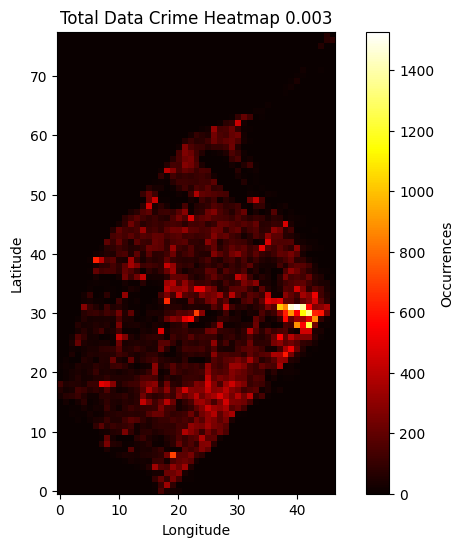

In [22]:
lat_bins = np.arange(lat_min, lat_max, 0.003)
lon_bins = np.arange(lon_min, lon_max, 0.003)

# print(lat_min, lat_max, len(lat_bins))
# print(lon_min, lon_max, len(lon_bins))

heatmap, lat_edges, lon_edges = np.histogram2d(df['Latitude'], df['Longitude'], bins=[lat_bins, lon_bins])
plot_heatmap(heatmap, "Total Data Crime Heatmap 0.003")

### Now we have a more managable image, but how do we know if the data is spatially correlated enough for a CNN to learn?
## Moran's I: a measure of spatial autocorrelation in data



In [23]:
def calc_moran(heatmap):
    # Flatten the data array to a 1D array
    data_flat = heatmap.flatten()
    
    # Create a spatial weights matrix
    # For example, using a distance-based weights matrix with a threshold
    coords = [(i, j) for i in range(heatmap.shape[0]) for j in range(heatmap.shape[1])]
    w = libpysal.weights.DistanceBand.from_array(coords, threshold=1.5)  # Adjust threshold as needed
    
    # Calculate Moran's I
    moran = esda.Moran(data_flat, w)
    
    # Output Moran's I value
    print(f"Global Moran's I: {moran.I}")
    print(f"p-value: {moran.p_sim}")
    print(f"Expected I: {moran.EI}")

calc_moran(heatmap)

Global Moran's I: 0.6212257217352999
p-value: 0.001
Expected I: -0.00027285129604365623


In [24]:
one_day_data = df[(df['IncidentDate'] >= '2024-05-31') & (df['IncidentDate'] < '2024-06-01')]
one_week_data = df[(df['IncidentDate'] >= '2024-03-01') & (df['IncidentDate'] < '2024-03-08')]
one_month_data = df[(df['IncidentDate'] >= '2024-01-01') & (df['IncidentDate'] < '2024-02-01')]
one_year_data = df[(df['IncidentDate'] >= '2023-01-01') & (df['IncidentDate'] < '2023-12-31')]

one_day_heatmap, _, _ = np.histogram2d(one_day_data['Latitude'], one_day_data['Longitude'], bins=[lat_bins, lon_bins])
one_week_heatmap, _, _ = np.histogram2d(one_week_data['Latitude'], one_week_data['Longitude'], bins=[lat_bins, lon_bins])
one_month_heatmap, _, _ = np.histogram2d(one_month_data['Latitude'], one_month_data['Longitude'], bins=[lat_bins, lon_bins])
one_year_heatmap, _, _ = np.histogram2d(one_year_data['Latitude'], one_year_data['Longitude'], bins=[lat_bins, lon_bins])


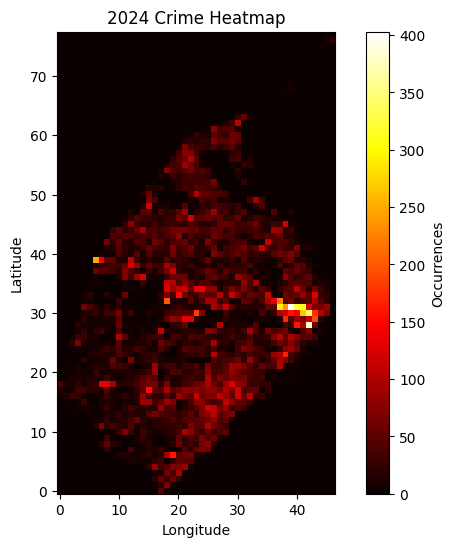

In [25]:
plot_heatmap(one_year_heatmap, '2023 Crime Heatmap')

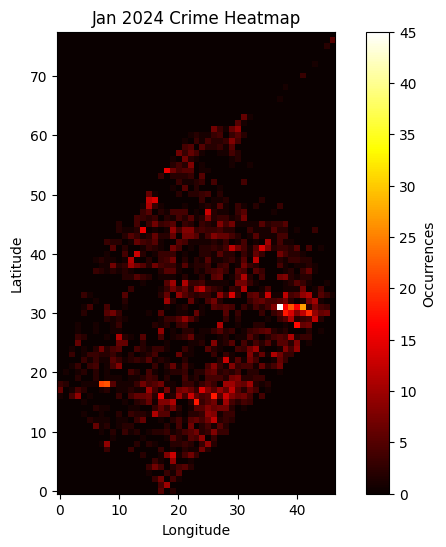

In [26]:
plot_heatmap(one_month_heatmap, 'January 2024 Crime Heatmap')

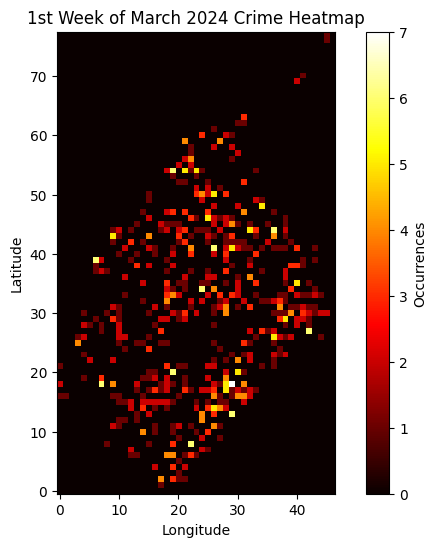

In [27]:
plot_heatmap(one_week_heatmap, '1st Week of March 2024 Crime Heatmap')

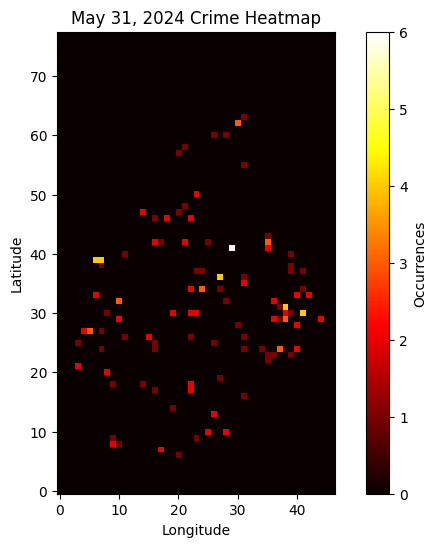

In [28]:
plot_heatmap(one_day_heatmap, 'May 31, 2024 Crime Heatmap')

In [29]:
print("~~~~~~~~~ONE YEAR MORAN'S I~~~~~~~~~")
calc_moran(one_year_heatmap)
print("~~~~~~~~~ONE MONTH MORAN'S I~~~~~~~~~")
calc_moran(one_month_heatmap)
print("~~~~~~~~~ONE WEEK MORAN'S I~~~~~~~~~")
calc_moran(one_week_heatmap)
print("~~~~~~~~~ONE DAY MORAN'S I~~~~~~~~~")
calc_moran(one_day_heatmap)

~~~~~~~~~ONE YEAR MORAN'S I~~~~~~~~~
Global Moran's I: 0.5730297433219982
p-value: 0.001
Expected I: -0.00027285129604365623
~~~~~~~~~ONE MONTH MORAN'S I~~~~~~~~~
Global Moran's I: 0.40809987880835114
p-value: 0.001
Expected I: -0.00027285129604365623
~~~~~~~~~ONE WEEK MORAN'S I~~~~~~~~~
Global Moran's I: 0.16996160132744825
p-value: 0.001
Expected I: -0.00027285129604365623
~~~~~~~~~ONE DAY MORAN'S I~~~~~~~~~
Global Moran's I: 0.06055673900416806
p-value: 0.001
Expected I: -0.00027285129604365623


## Using Local Moran's I to find correlated neighborhoods

C:\Users\jz043x\AppData\Local\Programs\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 38.
  W.__init__(self, neighbors, ids=ids, **kw)


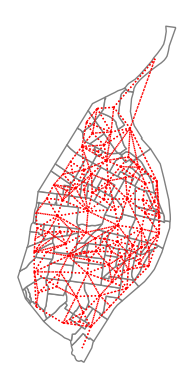

In [30]:
np.random.seed(42)  # For reproducibility

# Create a spatial weights matrix using Queen contiguity (neighbors touching)
w = Queen.from_dataframe(neighborhood_crimes, use_index=True)

ax = neighborhood_crimes.plot(edgecolor='grey', facecolor='w')
f,ax = w.plot(neighborhood_crimes, ax=ax, 
        edge_kws=dict(color='r', linestyle=':', linewidth=1),
        node_kws=dict(marker=''))
ax.set_axis_off()



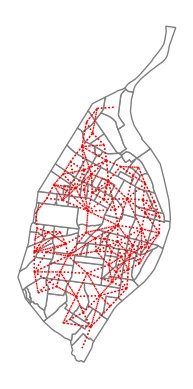

In [31]:
outlier_neighborhoods = neighborhood_crimes[(neighborhood_crimes['Population'] < 400) | (neighborhood_crimes['NHD_NAME'] == 'Princeton Heights')]
inlier_neighborhoods = neighborhood_crimes[(neighborhood_crimes['Population'] > 400) & (neighborhood_crimes['NHD_NAME'] != 'Princeton Heights')]

w = Queen.from_dataframe(inlier_neighborhoods, use_index=True)

ax = neighborhood_crimes.plot(edgecolor='grey', facecolor='w')
f,ax = w.plot(neighborhood_crimes, ax=ax, 
        edge_kws=dict(color='r', linestyle=':', linewidth=1),
        node_kws=dict(marker=''))
ax.set_axis_off()




C:\Users\jz043x\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\jz043x\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\jz043x\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is tr

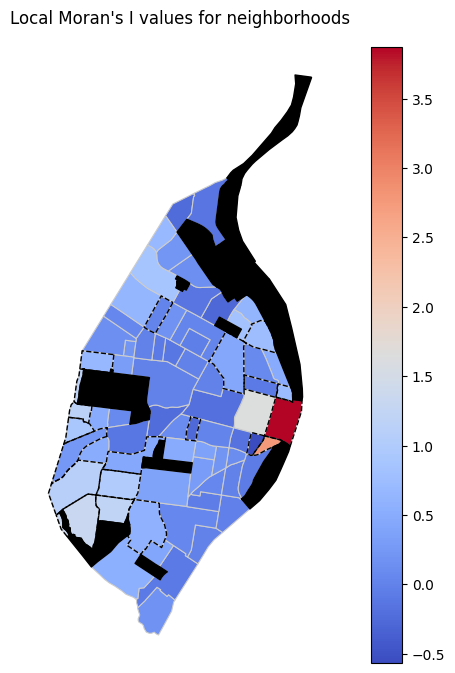

In [32]:
# Calculate local Moran's I values
moran_local = Moran_Local(inlier_neighborhoods['PopCrime'], w)

# Add the Moran's I values and p-values to the GeoDataFrame
inlier_neighborhoods['local_moran'] = moran_local.Is
inlier_neighborhoods['p_value'] = moran_local.p_sim

# Classify the neighborhoods into significant clusters at 0.05 significance level
inlier_neighborhoods['significant_cluster'] = moran_local.q
inlier_neighborhoods.loc[inlier_neighborhoods['p_value'] > 0.05, 'significant_cluster'] = 0

# Plot the neighborhoods with local Moran's I values
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
inlier_neighborhoods.plot(column='local_moran', cmap='coolwarm', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
outlier_neighborhoods.plot(ax=ax, color='black', edgecolor='black')

ax.set_title('Local Moran\'s I values for neighborhoods')
ax.set_axis_off()

# Add a legend for significant clusters
significant_clusters = inlier_neighborhoods[inlier_neighborhoods['significant_cluster'] != 0]
significant_clusters.plot(ax=ax, color='none', edgecolor='black', linewidth=1, linestyle='--')

# Show the plot
plt.show()